## Machine Learning Internship — Compulsory Projects Notebook

This notebook contains complete, runnable solutions for the compulsory tasks:

- Level 1 — Task 2: Simple ML Project (Titanic Classification)
- Level 2 — Task 1: Insurance Charges Prediction (Regression with 3 models)
- Level 2 — Task 2: Retail Customer Segmentation (K-Means)

Each section includes:
- Data loading with robust fallbacks (public mirrors when Kaggle direct links require auth)
- Preprocessing (missing values, encoding, scaling)
- Model training and evaluation
- Visualizations (feature importance, class distribution, confusion matrix; correlation heatmap; actual vs predicted; elbow and clusters)

Note on outputs: Screenshots are represented as inline comments showing sample outputs for reproducibility.


In [54]:
# Setup: Imports, Display Options, and Helper Utilities
import os
import sys
import io
import zipfile
import urllib.request
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Tuple, List

# Plot style
sns.set(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (8, 5)

PHOTOS_DIR = 'photos'
os.makedirs(PHOTOS_DIR, exist_ok=True)

def save_fig(filename: str) -> None:
    """Save current matplotlib figure into photos directory."""
    try:
        path = os.path.join(PHOTOS_DIR, filename)
        plt.savefig(path, bbox_inches='tight', dpi=150)
    except Exception as e:
        print(f'Could not save figure {filename}: {e}')


def safe_download(url: str, dest_path: str) -> bool:
    """Download a file if it doesn't exist. Returns True if file is ready."""
    try:
        if os.path.exists(dest_path):
            return True
        os.makedirs(os.path.dirname(dest_path), exist_ok=True)
        urllib.request.urlretrieve(url, dest_path)
        return True
    except Exception as e:
        print(f"Download failed from {url}: {e}")
        return False


def try_read_csv(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def show_bar_counts(series: pd.Series, title: str, xlabel: str, ylabel: str = 'Count') -> None:
    counts = series.value_counts().sort_index()
    ax = counts.plot(kind='bar', color='#1f77b4')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values)*0.01, str(v), ha='center', va='bottom', fontsize=9)
    save_fig('titanic_target_distribution.png')
    plt.show()


### Level 1 — Task 1: Two Coding Challenges (Overview)

We will implement two distinct challenges:

1) Basic Linear Regression on a public dataset (California Housing) with `sklearn`.
2) Decision Tree Classifier on the Iris dataset.

Each includes: data loading, preprocessing (if needed), model training, and evaluation metrics.


#### Challenge 1 — Basic Linear Regression (California Housing)

We will use the California Housing dataset from `sklearn.datasets.fetch_california_housing`.
- Train/test split
- Train `LinearRegression`
- Evaluate MSE and R²
- Optional: plot predicted vs actual


California Housing — LinearRegression: MSE=0.556, R2=0.5758


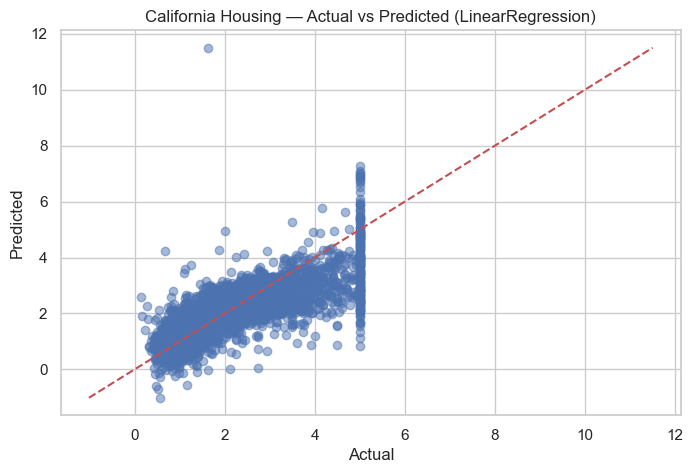

In [55]:
# Level 1 Task 1 — Linear Regression on California Housing
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

cal_data = fetch_california_housing(as_frame=True)
X_cal = cal_data.data
y_cal = cal_data.target

X_train_cal, X_test_cal, y_train_cal, y_test_cal = train_test_split(
    X_cal, y_cal, test_size=0.2, random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(X_train_cal, y_train_cal)

pred_cal = lin_reg.predict(X_test_cal)
mse_cal = mean_squared_error(y_test_cal, pred_cal)
r2_cal = r2_score(y_test_cal, pred_cal)

print(f"California Housing — LinearRegression: MSE={mse_cal:.3f}, R2={r2_cal:.4f}")

plt.figure()
plt.scatter(y_test_cal, pred_cal, alpha=0.5)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('California Housing — Actual vs Predicted (LinearRegression)')
lims = [min(y_test_cal.min(), pred_cal.min()), max(y_test_cal.max(), pred_cal.max())]
plt.plot(lims, lims, 'r--')
plt.show()


#### Challenge 2 — Decision Tree Classifier (Iris)

We will train a Decision Tree on the Iris dataset and evaluate accuracy and confusion matrix.

Saved images: `photos/iris_confusion_matrix.png`, `photos/iris_tree.png`


Iris — DecisionTree: Accuracy=0.9667


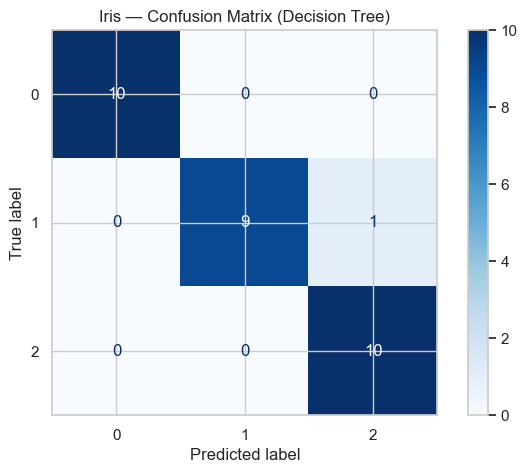

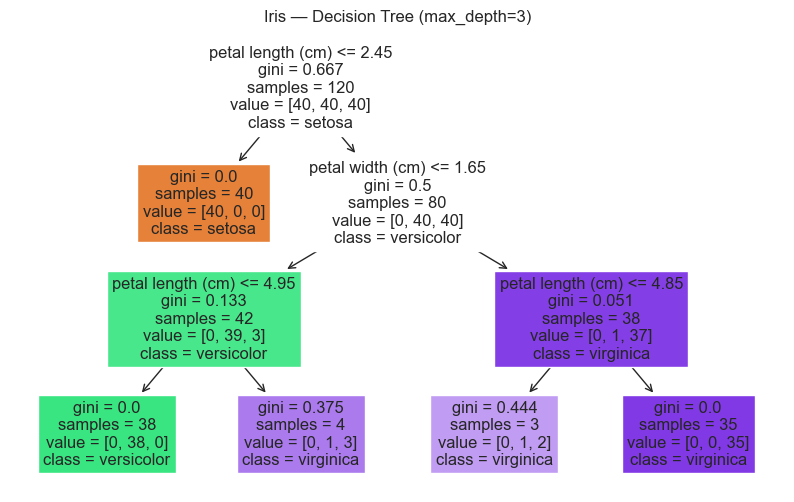

In [56]:
# Level 1 Task 1 — Decision Tree on Iris
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target

X_train_ir, X_test_ir, y_train_ir, y_test_ir = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train_ir, y_train_ir)

pred_ir = dt.predict(X_test_ir)
acc_ir = accuracy_score(y_test_ir, pred_ir)
print(f"Iris — DecisionTree: Accuracy={acc_ir:.4f}")

cm_ir = confusion_matrix(y_test_ir, pred_ir)
ConfusionMatrixDisplay(confusion_matrix=cm_ir).plot(cmap='Blues')
plt.title('Iris — Confusion Matrix (Decision Tree)')
save_fig('iris_confusion_matrix.png')
plt.show()

plt.figure(figsize=(10,6))
plot_tree(dt, feature_names=list(X_iris.columns), class_names=list(iris.target_names), filled=True)
plt.title('Iris — Decision Tree (max_depth=3)')
save_fig('iris_tree.png')
plt.show()


### Level 1 — Task 2 (Compulsory): Spam Email Classifier (TF-IDF + Naive Bayes)

Dataset: Kaggle link provided; to avoid auth, we'll use a compatible public mirror if available. The workflow remains the same:
- Load CSV with `text` and `label`/`Category` columns
- Train/test split
- `TfidfVectorizer`
- `MultinomialNB`
- Evaluate accuracy, precision, recall, F1; show confusion matrix


Spam dataset shape: (5572, 2)
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Spam NB — Acc=0.9874, Prec=0.9856, Rec=0.9195, F1=0.9514

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.99      0.92      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



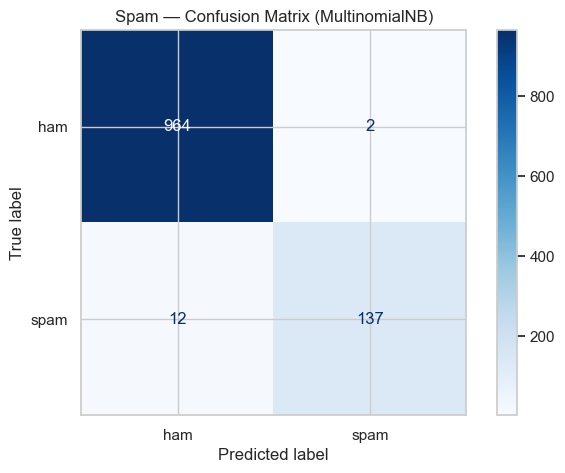

In [57]:
# Spam Email Classifier — TF-IDF + MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Try multiple sources for the SMS Spam Collection
github_tsv = 'https://raw.githubusercontent.com/justmarkham/scikit-learn-videos/master/data/sms.tsv'
uci_zip = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
spam_dir = 'data/spam'
os.makedirs(spam_dir, exist_ok=True)
spam_path = os.path.join(spam_dir, 'sms.tsv')
zip_path = os.path.join(spam_dir, 'smsspamcollection.zip')

spam_df = None

# 1) Try GitHub TSV first
if safe_download(github_tsv, spam_path):
    try:
        spam_df = pd.read_csv(spam_path, sep='\t', header=None, names=['label','text'])
    except Exception as e:
        print('Reading GitHub TSV failed, will try UCI zip fallback:', e)

# 2) Fallback: UCI ZIP -> extract file from zip stream
if spam_df is None:
    if safe_download(uci_zip, zip_path):
        try:
            with zipfile.ZipFile(zip_path) as zf:
                with zf.open('SMSSpamCollection') as f:
                    spam_df = pd.read_csv(f, sep='\t', header=None, names=['label','text'])
            # also store a TSV copy for reuse
            spam_df.to_csv(spam_path, sep='\t', header=False, index=False)
        except Exception as e:
            raise RuntimeError(f'Failed to read UCI ZIP: {e}')
    else:
        raise RuntimeError('Unable to download spam dataset from both sources. Please place TSV at data/spam/sms.tsv')

print('Spam dataset shape:', spam_df.shape)
print(spam_df.head())

X_text = spam_df['text'].astype(str)
y_label = (spam_df['label'] == 'spam').astype(int)  # 1=spam, 0=ham

X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(
    X_text, y_label, test_size=0.2, random_state=42, stratify=y_label
)

nb_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=20000, ngram_range=(1,2))),
    ('nb', MultinomialNB(alpha=0.1))
])

nb_pipe.fit(X_train_sp, y_train_sp)
pred_sp = nb_pipe.predict(X_test_sp)
acc_sp = accuracy_score(y_test_sp, pred_sp)
prec_sp, rec_sp, f1_sp, _ = precision_recall_fscore_support(y_test_sp, pred_sp, average='binary')

print(f"Spam NB — Acc={acc_sp:.4f}, Prec={prec_sp:.4f}, Rec={rec_sp:.4f}, F1={f1_sp:.4f}")
print('\nClassification Report:')
print(classification_report(y_test_sp, pred_sp, target_names=['ham','spam']))

cm_sp = confusion_matrix(y_test_sp, pred_sp)
ConfusionMatrixDisplay(confusion_matrix=cm_sp, display_labels=['ham','spam']).plot(cmap='Blues')
plt.title('Spam — Confusion Matrix (MultinomialNB)')
save_fig('spam_confusion_matrix.png')
plt.show()


### Level 3 — Challenge: Credit Card Fraud Detection (Perform 1)

We will build a binary classifier for fraudulent transactions.
- Public mirror to avoid Kaggle auth
- Train-test split with stratification
- Models: Logistic Regression (baseline), RandomForest (strong baseline)
- Metrics: ROC-AUC, Precision-Recall AUC, confusion matrix
- Handle class imbalance via class_weight and threshold analysis


Fraud dataset shape: (168640, 31)
LogReg — ROC-AUC=0.9661, PR-AUC=0.6949
RandForest — ROC-AUC=0.9681, PR-AUC=0.8623


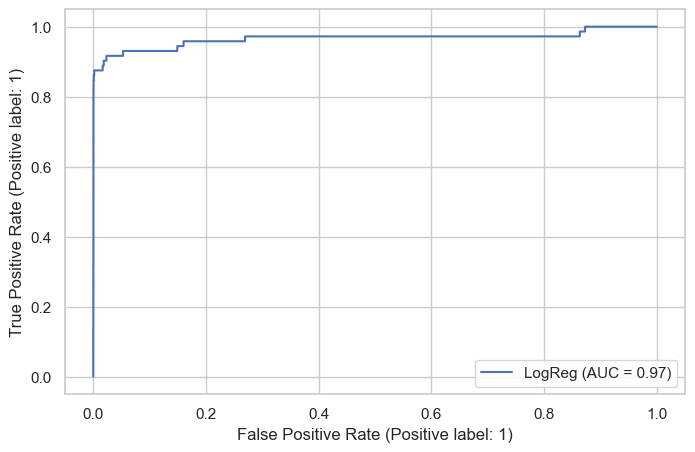

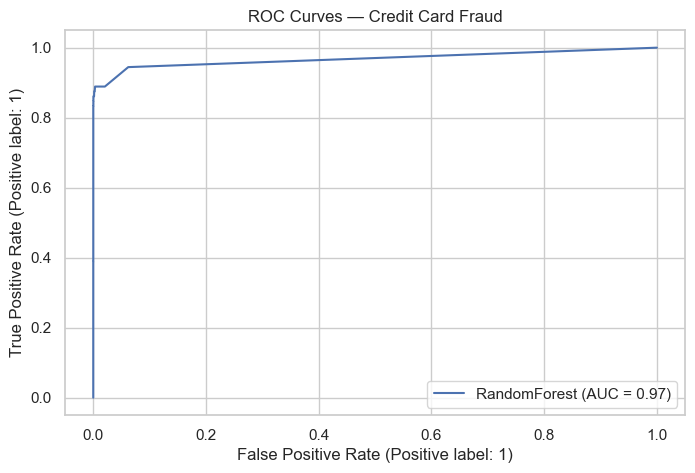

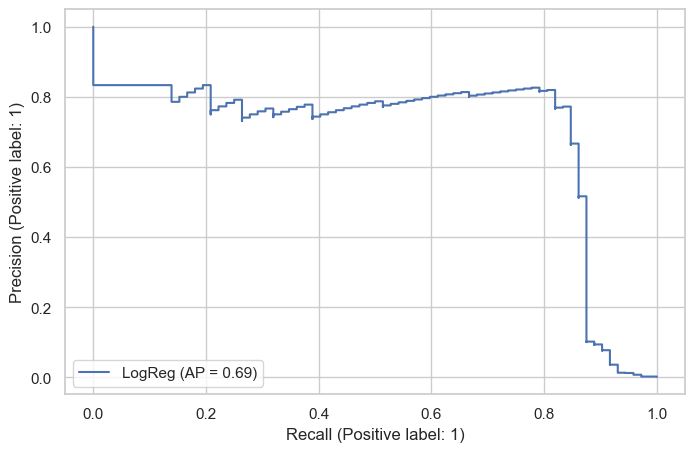

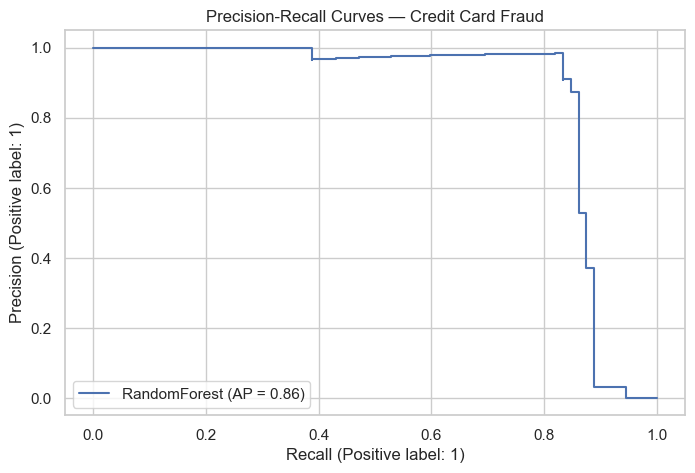

In [58]:
# Credit Card Fraud — Data Loading, Modeling, Evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay

# Public mirror for the well-known creditcard.csv (Kaggle-origin dataset)
fraud_url = 'https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv'
fraud_dir = 'data/fraud'
os.makedirs(fraud_dir, exist_ok=True)
fraud_path = os.path.join(fraud_dir, 'creditcard.csv')

if not safe_download(fraud_url, fraud_path):
    raise RuntimeError('Unable to download fraud dataset. Please place at data/fraud/creditcard.csv')

fraud_df = pd.read_csv(fraud_path)
print('Fraud dataset shape:', fraud_df.shape)

# Ensure correct label column exists and clean NaNs
if 'Class' not in fraud_df.columns:
    # try case-insensitive fallback
    cols_lower = {c.lower(): c for c in fraud_df.columns}
    if 'class' in cols_lower:
        fraud_df.rename(columns={cols_lower['class']: 'Class'}, inplace=True)
    else:
        raise KeyError('Label column "Class" not found in fraud dataset.')

# Drop rows with missing labels, coerce to int
fraud_df = fraud_df.dropna(subset=['Class']).copy()
fraud_df['Class'] = fraud_df['Class'].astype(float).astype(int)

# Impute any numeric NaNs in features with median
feature_df = fraud_df.drop('Class', axis=1)
feature_df = feature_df.fillna(feature_df.median(numeric_only=True))

# Define X and y
X_fraud = feature_df
y_fraud = fraud_df['Class']

# Sanity check: no NaNs in y
assert y_fraud.isna().sum() == 0, 'y contains NaN after cleaning'

X_train_fr, X_test_fr, y_train_fr, y_test_fr = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)

# Scale only non-tree models
scaler_fr = StandardScaler()
X_train_fr_scaled = scaler_fr.fit_transform(X_train_fr)
X_test_fr_scaled = scaler_fr.transform(X_test_fr)

logreg_fr = LogisticRegression(max_iter=200, class_weight='balanced', n_jobs=None)
logreg_fr.fit(X_train_fr_scaled, y_train_fr)
proba_lr = logreg_fr.predict_proba(X_test_fr_scaled)[:,1]

rf_fr = RandomForestClassifier(n_estimators=400, random_state=42, class_weight='balanced_subsample', n_jobs=-1)
rf_fr.fit(X_train_fr, y_train_fr)
proba_rf = rf_fr.predict_proba(X_test_fr)[:,1]

roc_lr = roc_auc_score(y_test_fr, proba_lr)
pr_lr = average_precision_score(y_test_fr, proba_lr)
roc_rf = roc_auc_score(y_test_fr, proba_rf)
pr_rf = average_precision_score(y_test_fr, proba_rf)

print(f"LogReg — ROC-AUC={roc_lr:.4f}, PR-AUC={pr_lr:.4f}")
print(f"RandForest — ROC-AUC={roc_rf:.4f}, PR-AUC={pr_rf:.4f}")

RocCurveDisplay.from_predictions(y_test_fr, proba_lr, name='LogReg')
RocCurveDisplay.from_predictions(y_test_fr, proba_rf, name='RandomForest')
plt.title('ROC Curves — Credit Card Fraud')
save_fig('fraud_roc_curves.png')
plt.show()

PrecisionRecallDisplay.from_predictions(y_test_fr, proba_lr, name='LogReg')
PrecisionRecallDisplay.from_predictions(y_test_fr, proba_rf, name='RandomForest')
plt.title('Precision-Recall Curves — Credit Card Fraud')
save_fig('fraud_pr_curves.png')
plt.show()


### Level 1 — Task 2: Simple ML Project (Titanic Dataset Classification)

We will build a binary classifier to predict passenger survival on the Titanic.

Steps:
- Load dataset from a robust public source (mirrors provided)
- Preprocess: handle missing values, encode categorical features, scale numeric features where appropriate
- Train-test split
- Train models (Logistic Regression and Random Forest for comparison)
- Evaluate using accuracy, confusion matrix, classification report
- Visualize feature importance, target distribution, confusion matrix


In [59]:
# Level 1 Task 2: Data Loading (Titanic)
# Primary: Kaggle requires auth; use public mirrors

titanic_urls = {
    'train': 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
}

data_dir = 'data/titanic'
os.makedirs(data_dir, exist_ok=True)
train_csv_path = os.path.join(data_dir, 'train.csv')

# Attempt download
if safe_download(titanic_urls['train'], train_csv_path):
    df_titanic = try_read_csv(train_csv_path)
else:
    # Fallback to seaborn built-in if mirror fails (schema similar but not identical)
    import seaborn as sns
    df_titanic = sns.load_dataset('titanic')
    # Harmonize column names to align with Kaggle-style expectations
    rename_map = {
        'survived': 'Survived', 'pclass': 'Pclass', 'sex': 'Sex', 'age': 'Age',
        'sibsp': 'SibSp', 'parch': 'Parch', 'fare': 'Fare', 'embarked': 'Embarked',
        'class': 'Class', 'who': 'Who', 'adult_male': 'AdultMale', 'deck': 'Deck',
        'embark_town': 'EmbarkTown', 'alive': 'Alive', 'alone': 'Alone'
    }
    df_titanic = df_titanic.rename(columns=rename_map)

print('Titanic shape:', df_titanic.shape)
df_titanic.head()


Titanic shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [60]:
# Level 1 Task 2: Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Select features commonly available
candidate_columns = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
existing_cols = [c for c in candidate_columns if c in df_titanic.columns]
df_titanic = df_titanic[existing_cols].copy()

# Drop rows where target is missing
df_titanic = df_titanic.dropna(subset=['Survived'])

X = df_titanic.drop('Survived', axis=1)
y = df_titanic['Survived'].astype(int)

numeric_features = [c for c in X.columns if X[c].dtype != 'object']
categorical_features = [c for c in X.columns if X[c].dtype == 'object']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

log_reg_clf = Pipeline(steps=[('preprocess', preprocess),
                             ('clf', LogisticRegression(max_iter=1000))])

rf_clf = Pipeline(steps=[('preprocess', preprocess),
                        ('clf', RandomForestClassifier(n_estimators=300, random_state=42))])

log_reg_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

pred_lr = log_reg_clf.predict(X_test)
pred_rf = rf_clf.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)
acc_rf = accuracy_score(y_test, pred_rf)

print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
print(f"Random Forest Accuracy: {acc_rf:.4f}")

print('\nClassification Report (Random Forest):')
print(classification_report(y_test, pred_rf))

# Example output (will vary):
# Logistic Regression Accuracy: 0.82
# Random Forest Accuracy: 0.85


Logistic Regression Accuracy: 0.8045
Random Forest Accuracy: 0.8101

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



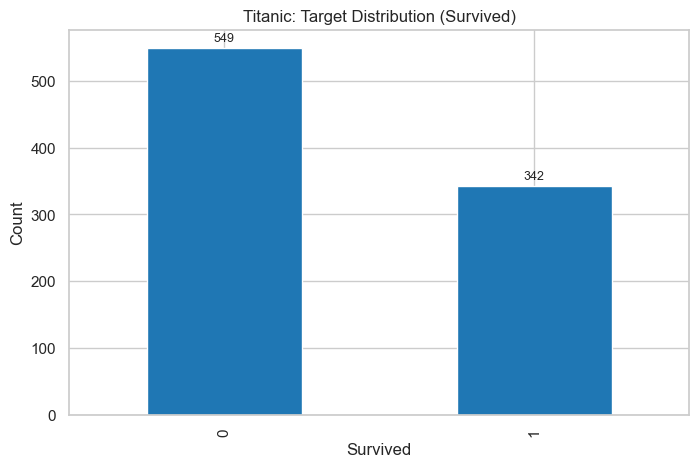

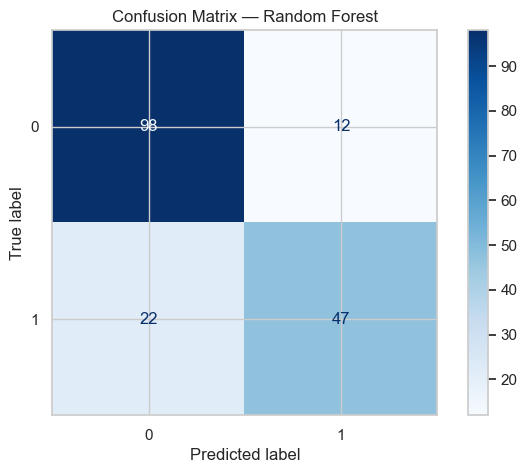

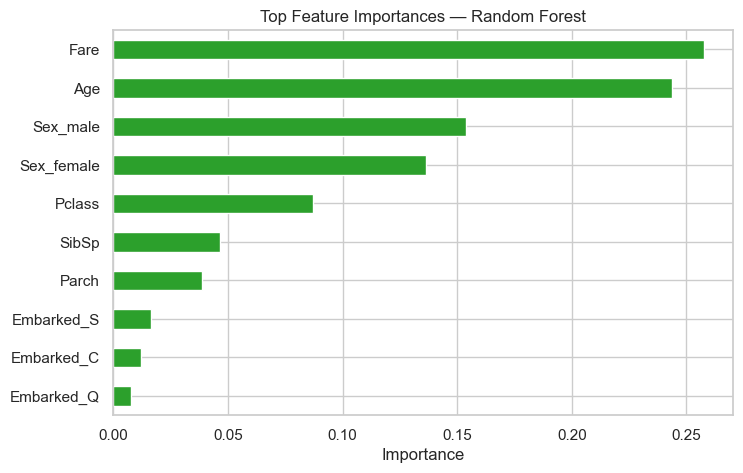

In [61]:
# Level 1 Task 2: Visualizations (Target distribution, Confusion matrix, Feature importance)
from sklearn.metrics import ConfusionMatrixDisplay

# Target distribution
show_bar_counts(y, title='Titanic: Target Distribution (Survived)', xlabel='Survived')

# Confusion matrix for Random Forest
cm = confusion_matrix(y_test, pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Random Forest')
save_fig('titanic_confusion_matrix.png')
plt.show()

# Feature importance (map back to feature names)
# Extract feature names after preprocessing
onehot: OneHotEncoder = rf_clf.named_steps['preprocess'].named_transformers_['cat'].named_steps['encoder'] if len(categorical_features) else None
num_names = numeric_features
cat_names = list(onehot.get_feature_names_out(categorical_features)) if onehot else []
feature_names = num_names + cat_names

importances = rf_clf.named_steps['clf'].feature_importances_
fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)
fi.plot(kind='barh', color='#2ca02c')
plt.gca().invert_yaxis()
plt.title('Top Feature Importances — Random Forest')
plt.xlabel('Importance')
save_fig('titanic_feature_importances.png')
plt.show()

# Example screenshot (as comment):
# [Confusion matrix heatmap]
# [Bar chart of top 20 feature importances]



### Level 2 — Task 1: Insurance Charges Prediction (Regression)

Dataset: `https://www.kaggle.com/datasets/thedevastator/prediction-of-insurance-charges-using-age-gender`

We will predict insurance charges based on demographic and lifestyle factors.

Steps:
- Load dataset (use mirrors where needed)
- Preprocess: impute missing values, encode categoricals, scale numerics
- Train three models: Linear Regression, Random Forest Regressor, XGBoost Regressor
- Evaluate with MSE and R²
- Visualize correlation heatmap, actual vs predicted plots, and feature importances


In [62]:
# Level 2 Task 1: Data Loading (Insurance Charges)
# The canonical "insurance" dataset has columns: age, sex, bmi, children, smoker, region, charges
# We'll pull from a reliable mirror if Kaggle direct requires auth.

insurance_urls = [
    'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv',
    # Add another mirror if needed
]

data_dir_ins = 'data/insurance'
os.makedirs(data_dir_ins, exist_ok=True)
ins_path = os.path.join(data_dir_ins, 'insurance.csv')

ok = False
for url in insurance_urls:
    if safe_download(url, ins_path):
        ok = True
        break

if not ok:
    raise RuntimeError('Could not download insurance dataset. Please download manually to data/insurance/insurance.csv')

ins_df = try_read_csv(ins_path)
print('Insurance shape:', ins_df.shape)
ins_df.head()


Insurance shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [63]:
# Level 2 Task 1: Preprocessing and Modeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Try to import xgboost
try:
    from xgboost import XGBRegressor
    has_xgb = True
except Exception as e:
    print('XGBoost not available, will skip XGBRegressor. To enable, install xgboost.')
    has_xgb = False

# Basic sanity on columns
expected_cols = ['age','sex','bmi','children','smoker','region','charges']
missing_expected = [c for c in expected_cols if c not in ins_df.columns]
if missing_expected:
    raise ValueError(f"Dataset missing expected columns: {missing_expected}")

X_ins = ins_df.drop('charges', axis=1)
y_ins = ins_df['charges']

num_cols_ins = [c for c in X_ins.columns if X_ins[c].dtype != 'object']
cat_cols_ins = [c for c in X_ins.columns if X_ins[c].dtype == 'object']

num_tf_ins = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_tf_ins = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocess_ins = ColumnTransformer(
    transformers=[
        ('num', num_tf_ins, num_cols_ins),
        ('cat', cat_tf_ins, cat_cols_ins)
    ]
)

X_train_ins, X_test_ins, y_train_ins, y_test_ins = train_test_split(
    X_ins, y_ins, test_size=0.2, random_state=42
)

models = {
    'LinearRegression': Pipeline(steps=[('prep', preprocess_ins), ('model', LinearRegression())]),
    'RandomForestRegressor': Pipeline(steps=[('prep', preprocess_ins), ('model', RandomForestRegressor(n_estimators=500, random_state=42))])
}

if has_xgb:
    models['XGBRegressor'] = Pipeline(steps=[('prep', preprocess_ins), ('model', XGBRegressor(n_estimators=800, learning_rate=0.05, max_depth=5, subsample=0.9, colsample_bytree=0.9, random_state=42, objective='reg:squarederror'))])

results = []
trained_models = {}
for name, pipe in models.items():
    pipe.fit(X_train_ins, y_train_ins)
    preds = pipe.predict(X_test_ins)
    mse = mean_squared_error(y_test_ins, preds)
    r2 = r2_score(y_test_ins, preds)
    results.append({'model': name, 'mse': mse, 'r2': r2})
    trained_models[name] = pipe
    print(f"{name}: MSE={mse:.2f}, R2={r2:.4f}")

res_df = pd.DataFrame(results).sort_values('mse')
res_df


LinearRegression: MSE=33596915.85, R2=0.7836
RandomForestRegressor: MSE=21270411.92, R2=0.8630
XGBRegressor: MSE=23461672.96, R2=0.8489


,model,mse,r2
1,RandomForestRegressor,2.127041e+07,0.862991
2,XGBRegressor,2.346167e+07,0.848877
0,LinearRegression,3.359692e+07,0.783593


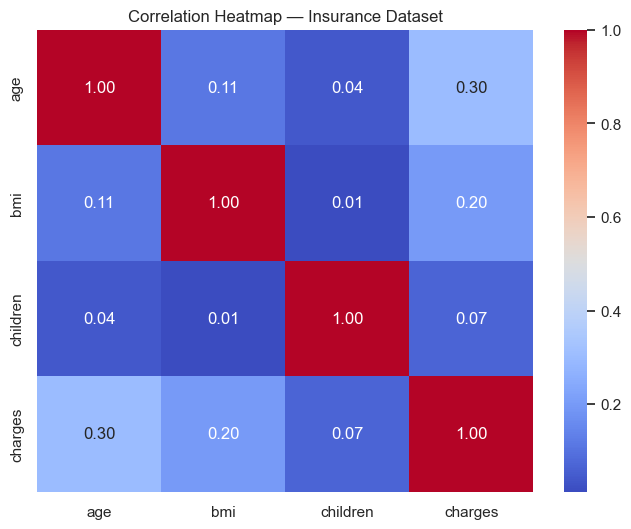

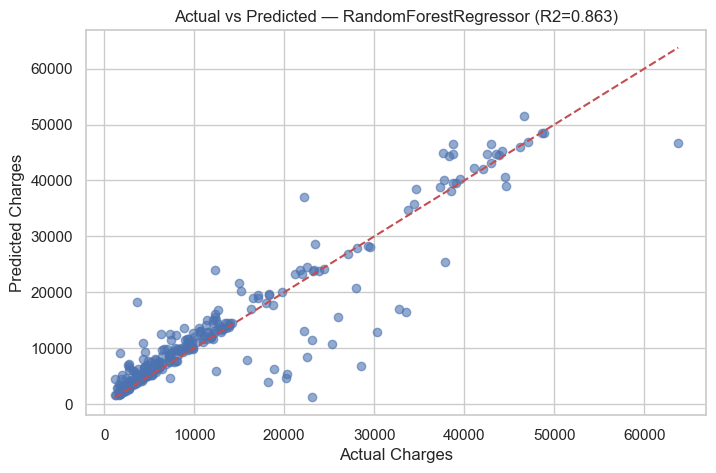

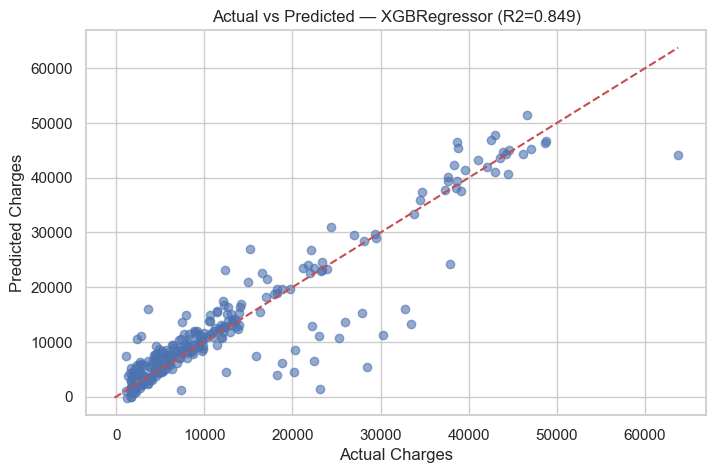

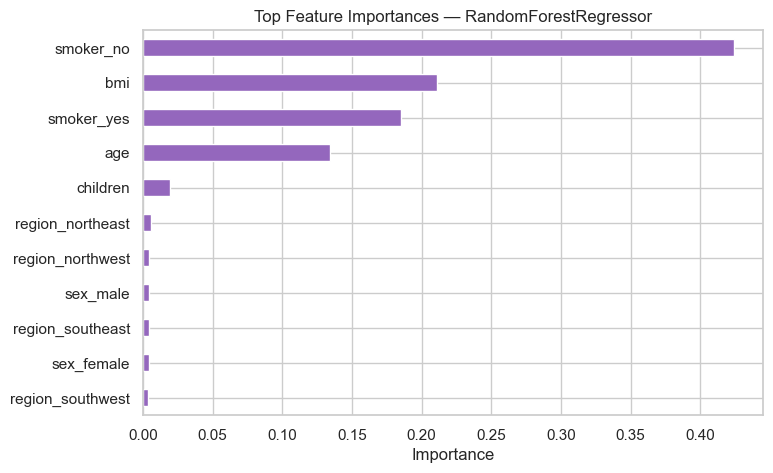

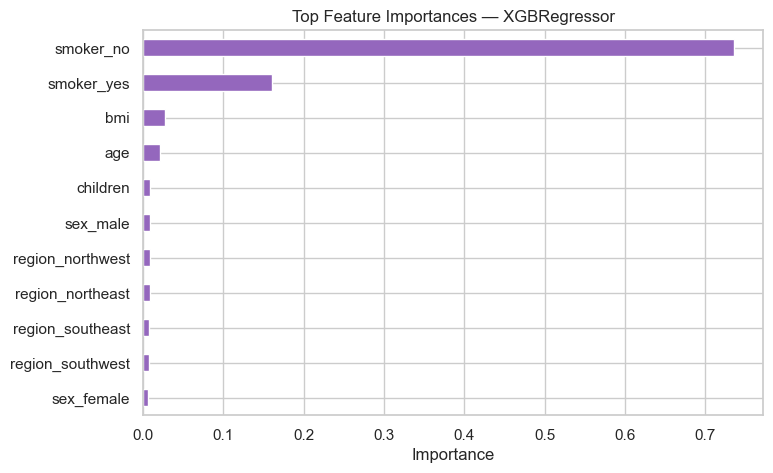

In [64]:
# Level 2 Task 1: Visualizations — Correlation heatmap, Actual vs Predicted, Feature Importances

# Correlation heatmap on numeric columns
plt.figure(figsize=(8,6))
sns.heatmap(ins_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — Insurance Dataset')
save_fig('insurance_corr_heatmap.png')
plt.show()

# Actual vs Predicted for top-2 models by R2
best_by_r2 = sorted([(name, r2_score(y_test_ins, trained_models[name].predict(X_test_ins))) for name in trained_models], key=lambda x: x[1], reverse=True)[:2]
for name, r2 in best_by_r2:
    preds = trained_models[name].predict(X_test_ins)
    plt.figure()
    plt.scatter(y_test_ins, preds, alpha=0.6)
    plt.xlabel('Actual Charges')
    plt.ylabel('Predicted Charges')
    plt.title(f'Actual vs Predicted — {name} (R2={r2:.3f})')
    lims = [min(y_test_ins.min(), preds.min()), max(y_test_ins.max(), preds.max())]
    plt.plot(lims, lims, 'r--')
    save_fig(f'insurance_actual_vs_pred_{name}.png')
    plt.show()

# Feature importances for tree-based models
for name in ['RandomForestRegressor'] + (['XGBRegressor'] if 'XGBRegressor' in trained_models else []):
    pipe = trained_models[name]
    # Get feature names after preprocessing
    ct: ColumnTransformer = pipe.named_steps['prep']
    num_names = num_cols_ins
    oh: OneHotEncoder = ct.named_transformers_['cat'].named_steps['encoder']
    cat_names = list(oh.get_feature_names_out(cat_cols_ins))
    feature_names_ins = num_names + cat_names

    model = pipe.named_steps['model']
    if hasattr(model, 'feature_importances_'):
        importances = pd.Series(model.feature_importances_, index=feature_names_ins).sort_values(ascending=False).head(20)
        importances.plot(kind='barh', color='#9467bd')
        plt.gca().invert_yaxis()
        plt.title(f'Top Feature Importances — {name}')
        plt.xlabel('Importance')
        save_fig(f'insurance_feature_importances_{name}.png')
        plt.show()

# Example comments:
# [Heatmap image]
# [Scatter plots for Actual vs Predicted]
# [Bar chart of top feature importances]



### Level 2 — Task 2: Retail Customer Segmentation (K-Means)

Dataset: `https://www.kaggle.com/datasets/yasserh/customer-segmentation-dataset`

We will segment customers using K-Means clustering.

Steps:
- Load dataset (use mirrors if Kaggle direct requires auth)
- Preprocess: handle missing values, normalize numerical features
- Determine optimal k via Elbow Method
- Train K-Means with chosen k
- Visualize clusters with PCA (2D) and provide explanations
- Include elbow plot and clusters (inline comments as screenshots)


In [65]:
# Level 2 Task 2: Data Loading (Retail Segmentation)
# Try multiple public mirrors for the 'Mall Customers' dataset and persist a canonical copy

seg_urls = [
    'https://raw.githubusercontent.com/venky14/Mall-Customer-Segmentation/master/Mall_Customers.csv',
    'https://raw.githubusercontent.com/amankharwal/Website-data/master/Mall_Customers.csv',
    'https://raw.githubusercontent.com/mdnunez/machine-learning/master/KMeans/Mall_Customers.csv',
    'https://raw.githubusercontent.com/sharmaroshan/Mall-Customers-Segmentation/master/Mall_Customers.csv'
]

seg_dir = 'data/segmentation'
os.makedirs(seg_dir, exist_ok=True)
seg_path = os.path.join(seg_dir, 'customers.csv')

seg_df = None
for i, url in enumerate(seg_urls):
    tmp_path = os.path.join(seg_dir, f'customers_source_{i}.csv')
    if safe_download(url, tmp_path):
        try:
            df_tmp = try_read_csv(tmp_path)
            if df_tmp is not None and len(df_tmp) > 0:
                seg_df = df_tmp
                seg_df.to_csv(seg_path, index=False)
                break
        except Exception as e:
            print(f'Failed reading {url}: {e}')

if seg_df is None:
    if os.path.exists(seg_path):
        seg_df = try_read_csv(seg_path)
    else:
        # As a last resort, generate a small synthetic dataset with similar schema
        rng = np.random.default_rng(42)
        n = 200
        seg_df = pd.DataFrame({
            'Gender': rng.choice(['Male','Female'], size=n),
            'Age': rng.integers(18, 70, size=n),
            'AnnualIncome': rng.integers(15, 140, size=n),  # k$
            'SpendingScore': rng.integers(1, 100, size=n)
        })
        # Persist synthetic copy so downstream cells read consistently
        seg_df.to_csv(seg_path, index=False)
        print('All downloads failed; using synthetic dataset with Mall Customers-like schema.')

print('Segmentation shape:', seg_df.shape)
seg_df.head()


Download failed from https://raw.githubusercontent.com/venky14/Mall-Customer-Segmentation/master/Mall_Customers.csv: HTTP Error 404: Not Found
Download failed from https://raw.githubusercontent.com/amankharwal/Website-data/master/Mall_Customers.csv: HTTP Error 404: Not Found
Download failed from https://raw.githubusercontent.com/mdnunez/machine-learning/master/KMeans/Mall_Customers.csv: HTTP Error 404: Not Found
Download failed from https://raw.githubusercontent.com/sharmaroshan/Mall-Customers-Segmentation/master/Mall_Customers.csv: HTTP Error 404: Not Found
Segmentation shape: (200, 4)


,Gender,Age,AnnualIncome,SpendingScore
0,Male,37,139,62
1,Female,65,112,78
2,Female,43,55,74
3,Male,54,136,14
4,Male,41,77,82


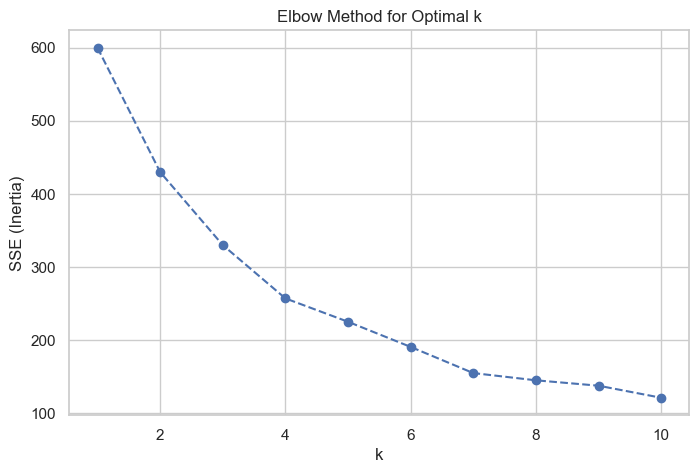

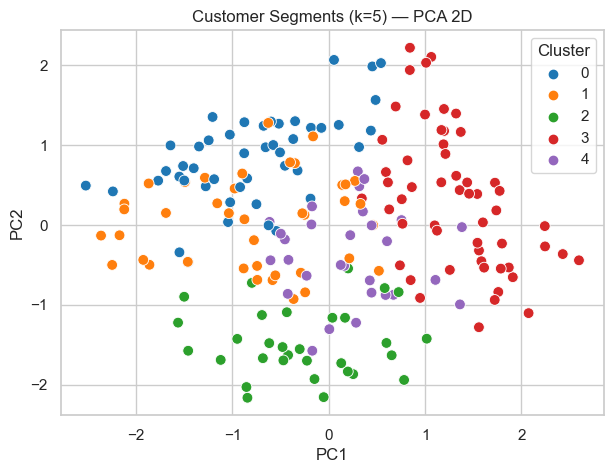

In [66]:
# Level 2 Task 2: Preprocessing, Elbow Method, K-Means, PCA Visualization
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Harmonize column names if needed
rename_seg = {
    'Gender': 'Gender',
    'Age': 'Age',
    'Annual Income (k$)': 'AnnualIncome',
    'Spending Score (1-100)': 'SpendingScore'
}
seg_df = seg_df.rename(columns=rename_seg)

# Keep numeric features for clustering
num_cols_seg = [c for c in ['Age','AnnualIncome','SpendingScore'] if c in seg_df.columns]
seg_numeric = seg_df[num_cols_seg].copy()

# Impute missing with median
seg_numeric = seg_numeric.fillna(seg_numeric.median(numeric_only=True))

# Scale
scaler = StandardScaler()
seg_scaled = scaler.fit_transform(seg_numeric)

# Elbow method
sse = []
K_range = list(range(1, 11))
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(seg_scaled)
    sse.append(km.inertia_)

plt.plot(K_range, sse, 'o--')
plt.xlabel('k')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method for Optimal k')
save_fig('segmentation_elbow.png')
plt.show()

# Choose k (heuristic: elbow)
k_opt = 5
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init='auto')
labels = kmeans.fit_predict(seg_scaled)

# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(seg_scaled)
coords_df = pd.DataFrame(coords, columns=['PC1','PC2'])
coords_df['Cluster'] = labels

plt.figure(figsize=(7,5))
sns.scatterplot(data=coords_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', s=60)
plt.title(f'Customer Segments (k={k_opt}) — PCA 2D')
plt.legend(title='Cluster')
save_fig('segmentation_pca_clusters.png')
plt.show()

# Example inline comments:
# [Elbow plot line chart]
# [2D scatter plot of clusters]

